# Import Libraries

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Read dataset 

In [7]:
quiz_data = pd.DataFrame({
    "study_hours": 
[4.8,11.4,8.9,7.4,2.3,2.3,1.2,10.5,7.4,8.6,0.7,11.7,10.1,2.9,2.6,2.6,4.0,6.5,5.5,3.8,7.5,2.1,3.9,4.7,5.7,9.5,2.8,6.4,7.3,1.0,7.5,2.5,1.2,11.4,11.6,9.8,4.0,1.6,8.4,5.6,1.9,6.2,0.9,11.0,3.5,8.1,4.1,6.5,6.8,2.6,11.7,9.4,11.3,10.8,7.4,11.1,1.5,2.8,1.0,4.2],
    "videos_watched": 
[15,12,17,14,20,23,24,12,8,14,12,0,24,6,8,23,0,11,7,23,10,18,16,7,2,2,0,4,9,6,8,6,8,7,11,1,0,15,22,22,23,4,2, 11,7,21,2,0,2,4,14,13,2,0,4,22,13,6,8,14],
    "practice_solved": 
[14,25,12,31,38,31,3,29,36,22,38,14,28,35,12,31,6,21,27,1,5,27,27,19,29,10,27,24,38,32,0,26,12,2,38,5,7,26,8,36,32,23,14,31,31,23,11,38,1,2,36,16,1,1,27,22,36,31,32,0],
    "quiz_score": 
[59.7,94.2,82.2,83.1,72.2,62.8,43.3,97.3,78.1,88.6,61.2,86.6,97.9,59.2,43.3,72.4,48.4,74.1,66.6,54.6,67.3,55.2,68.7,54.5,67.1,69.7,47.2,62.9,81.4,50.7,64.3,53.8,44.5,88.3,100.0,67.1,36.4,59.6,85.4,80.9,68.6,69.8,35.0,100.0,60.6,82.2,50.8,77.4,55.7,32.3,100.0,77.8,76.1,74.3,74.4,100.0,55.3,56.6,44.6,47.0]
})

quiz_data.head(5)

,study_hours,videos_watched,practice_solved,quiz_score
0,4.8,15,14,59.7
1,11.4,12,25,94.2
2,8.9,17,12,82.2
3,7.4,14,31,83.1
4,2.3,20,38,72.2


# Split train and test dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    quiz_data[['videos_watched', 'study_hours', 'practice_solved']], 
    quiz_data['quiz_score'], random_state=42)

# train model

In [12]:
lin_regr = LinearRegression()
lin_regr.fit(X_train, y_train)

LinearRegression()

# Calculate metrics

In [60]:
y_pred = lin_regr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mse: {mse:.2f}, mae: {mae:.2f}, r2: {r2:.2f}")
results_df = pd.DataFrame({"mse": [mse], "mae": [mae], "r2": [r2]})

mse: 16.38, mae: 3.09, r2: 0.95


# Plot Diagrams

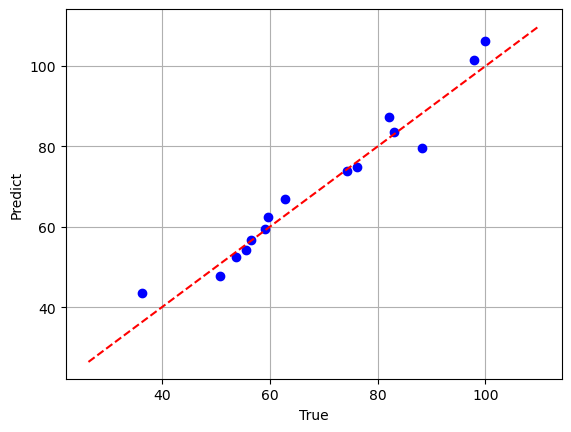

In [70]:
identity = np.linspace(y_test.min()-10, y_test.max()+10)
plt.figure()
plt.plot(y_test.values.ravel(), y_pred, 'bo')
plt.plot(identity, identity, 'r--')
plt.xlabel("True")
plt.ylabel("Predict")
plt.grid(True)
plt.show()

In [43]:
print(y_test.shape, y_pred.shape)
print(X_test.shape)

(15,) (15,)
(15, 3)


# Display coefs with related features names

In [61]:
coef_df = pd.DataFrame([lin_regr.coef_], columns=['videos_watched', 'study_hours', 'practice_solved'])

In [62]:
results_df

,mse,mae,r2
0,16.376364,3.087589,0.948799


In [63]:
coef_df

,videos_watched,study_hours,practice_solved
0,0.741684,4.565066,0.588548


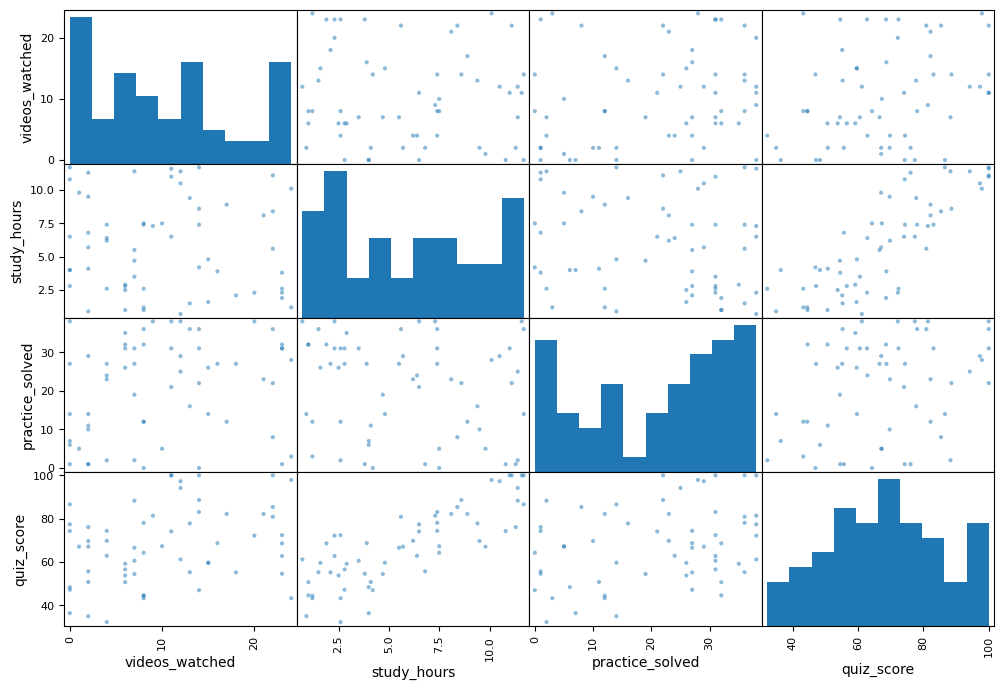

In [69]:
from pandas.plotting import scatter_matrix

attributes = ['videos_watched', 'study_hours', 'practice_solved', 'quiz_score']
scatter_matrix(quiz_data[attributes], figsize=(12, 8))
plt.show()

ب: هم با شهود و هم با دیتاست همخوانی دارد

ج: مدل تعمیم پذیر نبوده در این نقاط. میتواند گفت رابطه خطی بین فیچرها و برچسب در این نقاط وجود ندارد یا فیچرها و عوامل دیگری بر نمره تاثیر گذاشته اند.

د: به دلیل اهمیت پایین ضریب، تغییر کمی خواهیم داشت. اگر ارزش ضریب خیلی خیلی پایین بود می‌توانست تغییری روی ندهد.